<a href="https://www.kaggle.com/code/sonawanelalitsunil/global-product-inventory-2025-ml-21-30?scriptVersionId=229515576" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/global-product-inventory-dataset-2025/products.csv


## Title: Global Product Inventory 2025

### Description: A comprehensive dataset of global product inventories across various industries, including stock levels, categories, and locations for 2025.

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/global-product-inventory-dataset-2025/products.csv')

In [3]:
df.head()

,Product ID,Product Name,Product Category,Product Description,Price,Stock Quantity,Warranty Period,Product Dimensions,Manufacturing Date,Expiration Date,SKU,Product Tags,Color/Size Variations,Product Ratings
0,93TGNAY7,Laptop,Home Appliances,Product_XU5QX,253.17,3,2,16x15x15 cm,2023-01-01,2026-01-01,8NMFZ4,"VNU,NZ6",Green/Large,2
1,TYYZ5AV7,Smartphone,Clothing,Product_NRUMS,214.37,92,2,15x19x19 cm,2023-03-15,2025-01-01,7P5YCW,"ZJA,0D3",Red/Small,2
2,5C94FGTQ,Headphones,Clothing,Product_IT7HG,475.29,19,2,9x6x6 cm,2023-03-15,2026-01-01,YW5BME,"ZNG,MAP",Red/Small,1
3,XBHKYPQB,Monitor,Clothing,Product_8SBDO,403.33,40,1,7x13x5 cm,2023-01-01,2026-01-01,65MQC3,"RPP,M40",Green/Large,1
4,728GCZFU,Laptop,Home Appliances,Product_54FAF,229.81,32,2,20x20x19 cm,2023-07-30,2026-01-01,RLCBRW,"R8U,X46",Blue/Medium,4


In [4]:
df.tail()

,Product ID,Product Name,Product Category,Product Description,Price,Stock Quantity,Warranty Period,Product Dimensions,Manufacturing Date,Expiration Date,SKU,Product Tags,Color/Size Variations,Product Ratings
9995,J29B6RDI,Headphones,Clothing,Product_NI8C7,21.48,91,3,10x16x9 cm,2023-03-15,2026-01-01,0IQPXX,"M81,8WN",Blue/Medium,1
9996,L1HL7437,Laptop,Clothing,Product_8RR6T,403.92,19,2,13x8x5 cm,2023-01-01,2024-01-01,HW1HV1,"0UM,L4B",Red/Small,4
9997,FD57S4E1,Laptop,Home Appliances,Product_GYAWW,484.46,13,2,5x15x15 cm,2023-01-01,2024-01-01,MKJ0UW,"GO4,EZE",Red/Small,1
9998,RPYLOB1M,Headphones,Clothing,Product_K3M9M,411.63,79,1,17x11x17 cm,2023-07-30,2026-01-01,INSC1B,"0QB,U55",Red/Small,1
9999,3JWTGTOM,Laptop,Clothing,Product_I0ACF,74.38,81,1,6x6x16 cm,2023-01-01,2025-01-01,UH0U3R,"C5R,TZN",Blue/Medium,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Product ID             10000 non-null  object 
 1   Product Name           10000 non-null  object 
 2   Product Category       10000 non-null  object 
 3   Product Description    10000 non-null  object 
 4   Price                  10000 non-null  float64
 5   Stock Quantity         10000 non-null  int64  
 6   Warranty Period        10000 non-null  int64  
 7   Product Dimensions     10000 non-null  object 
 8   Manufacturing Date     10000 non-null  object 
 9   Expiration Date        10000 non-null  object 
 10  SKU                    10000 non-null  object 
 11  Product Tags           10000 non-null  object 
 12  Color/Size Variations  10000 non-null  object 
 13  Product Ratings        10000 non-null  int64  
dtypes: float64(1), int64(3), object(10)
memory usage: 1.1+ 

In [6]:
df.describe()

,Price,Stock Quantity,Warranty Period,Product Ratings
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,254.665715,50.647100,2.014000,3.004700
std,142.755688,28.901977,0.817968,1.419676
min,10.220000,1.000000,1.000000,1.000000
25%,129.985000,25.000000,1.000000,2.000000
50%,253.425000,51.000000,2.000000,3.000000
75%,379.970000,76.000000,3.000000,4.000000
max,499.970000,100.000000,3.000000,5.000000


In [7]:
df.isnull().sum()

Product ID               0
Product Name             0
Product Category         0
Product Description      0
Price                    0
Stock Quantity           0
Warranty Period          0
Product Dimensions       0
Manufacturing Date       0
Expiration Date          0
SKU                      0
Product Tags             0
Color/Size Variations    0
Product Ratings          0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.dtypes

Product ID                object
Product Name              object
Product Category          object
Product Description       object
Price                    float64
Stock Quantity             int64
Warranty Period            int64
Product Dimensions        object
Manufacturing Date        object
Expiration Date           object
SKU                       object
Product Tags              object
Color/Size Variations     object
Product Ratings            int64
dtype: object

In [10]:
df.shape

(10000, 14)

In [11]:
df.columns

Index(['Product ID', 'Product Name', 'Product Category', 'Product Description',
       'Price', 'Stock Quantity', 'Warranty Period', 'Product Dimensions',
       'Manufacturing Date', 'Expiration Date', 'SKU', 'Product Tags',
       'Color/Size Variations', 'Product Ratings'],
      dtype='object')

## Data visualizations

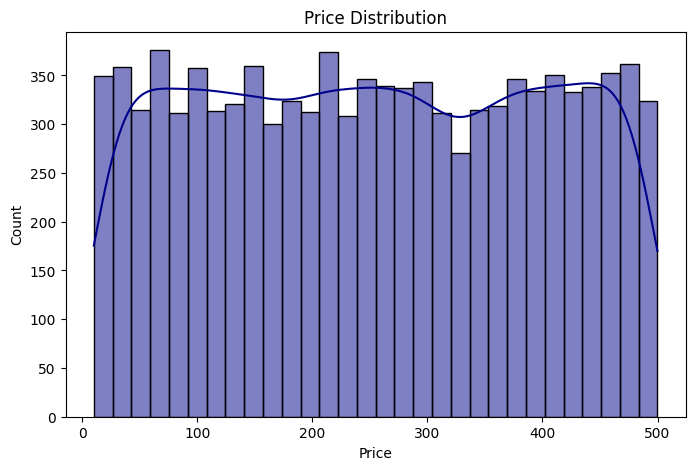

In [12]:
# 1. Price Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['Price'], bins=30, kde=True, color='darkblue')
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

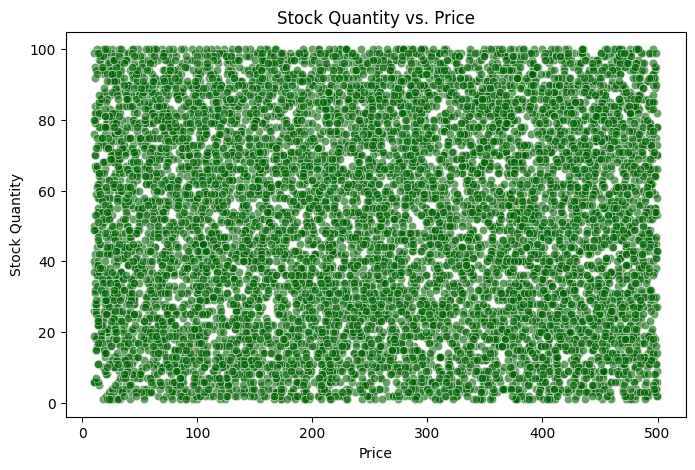

In [13]:
# 2. Stock Quantity vs. Price
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['Price'], y=df['Stock Quantity'], alpha=0.6, color='darkgreen')
plt.title("Stock Quantity vs. Price")
plt.xlabel("Price")
plt.ylabel("Stock Quantity")
plt.show()

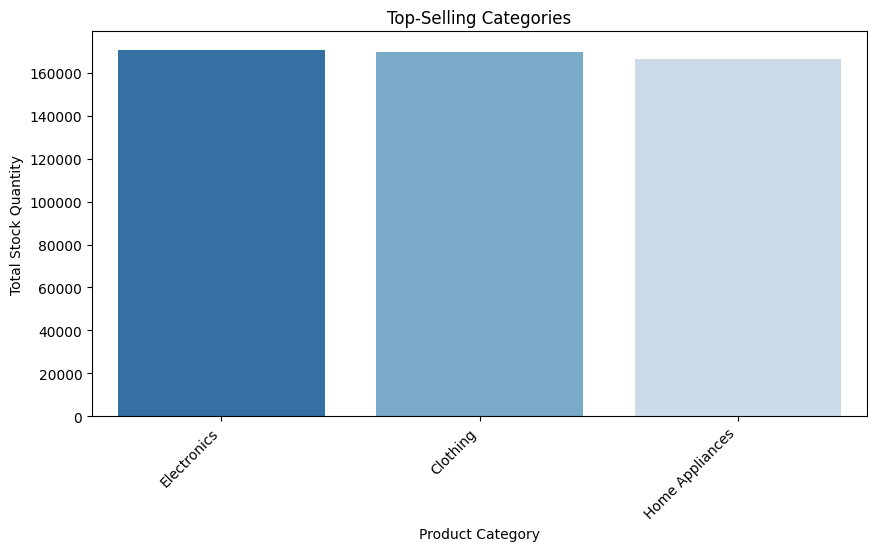

In [14]:
# 3. Top-Selling Categories
plt.figure(figsize=(10, 5))
category_stock = df.groupby("Product Category")["Stock Quantity"].sum().sort_values(ascending=False)
sns.barplot(x=category_stock.index, y=category_stock.values, palette='Blues_r')
plt.xticks(rotation=45, ha='right')
plt.title("Top-Selling Categories")
plt.xlabel("Product Category")
plt.ylabel("Total Stock Quantity")
plt.show()

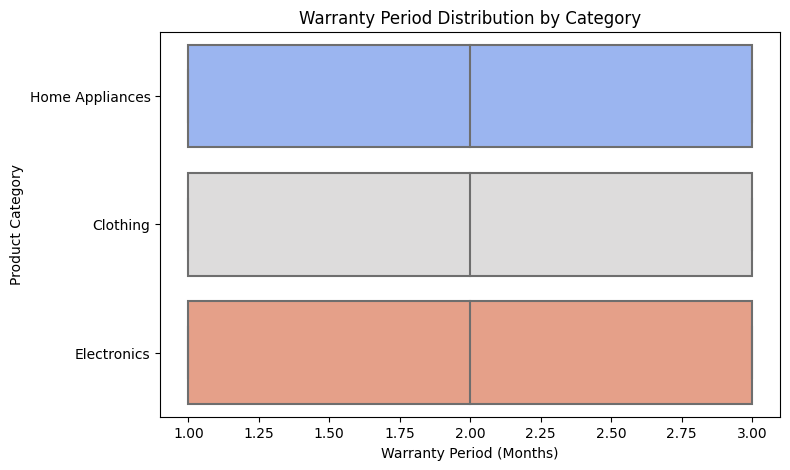

In [15]:
# 4. Warranty Period Distribution
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Warranty Period'], y=df['Product Category'], palette='coolwarm')
plt.title("Warranty Period Distribution by Category")
plt.xlabel("Warranty Period (Months)")
plt.ylabel("Product Category")
plt.show()

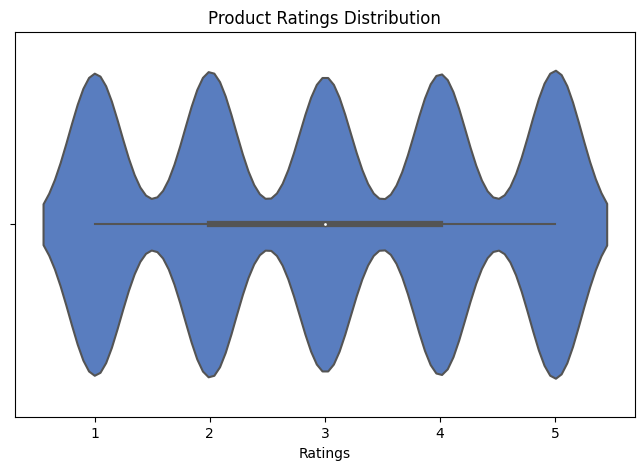

In [16]:
# 5. Product Ratings Distribution
plt.figure(figsize=(8, 5))
sns.violinplot(x=df['Product Ratings'], palette='muted')
plt.title("Product Ratings Distribution")
plt.xlabel("Ratings")
plt.show()

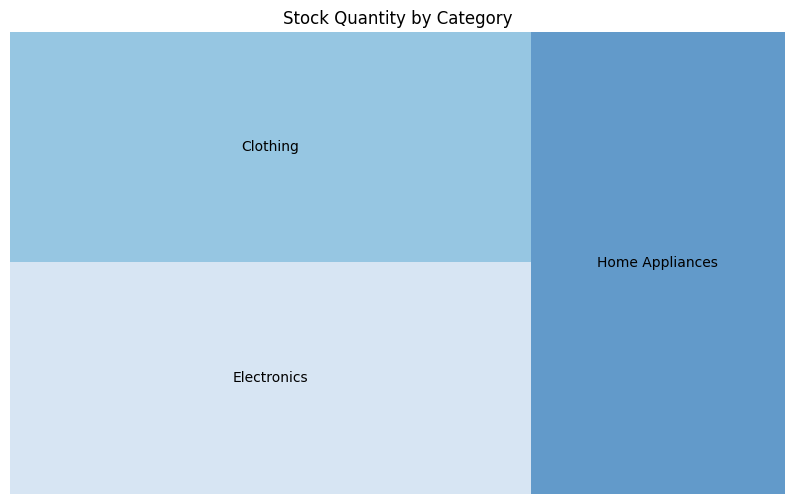

In [17]:
# 6. Stock Quantity by Product Category (Treemap)
import squarify
plt.figure(figsize=(10, 6))
squarify.plot(sizes=category_stock.values, label=category_stock.index, alpha=0.7, color=sns.color_palette("Blues", len(category_stock)))
plt.title("Stock Quantity by Category")
plt.axis("off")
plt.show()

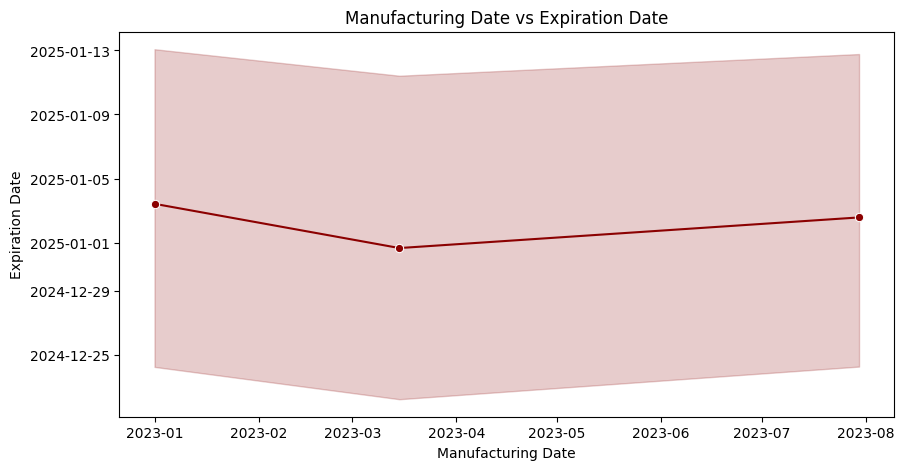

In [18]:
# 7. Manufacturing Date vs. Expiration Date
plt.figure(figsize=(10, 5))
df['Manufacturing Date'] = pd.to_datetime(df['Manufacturing Date'])
df['Expiration Date'] = pd.to_datetime(df['Expiration Date'])
sns.lineplot(x=df['Manufacturing Date'], y=df['Expiration Date'], marker='o', linestyle='-', color='darkred')
plt.title("Manufacturing Date vs Expiration Date")
plt.xlabel("Manufacturing Date")
plt.ylabel("Expiration Date")
plt.show()

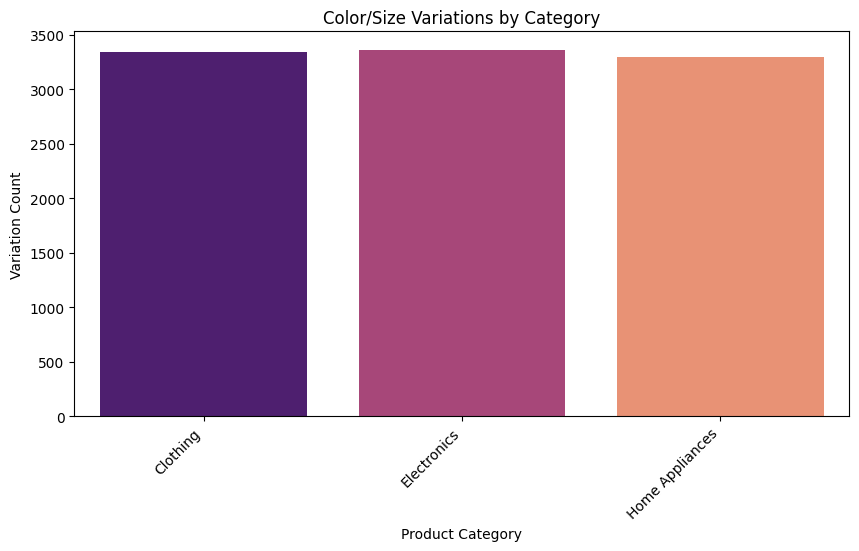

In [19]:
# 8. Color/Size Variations by Category
plt.figure(figsize=(10, 5))
variation_counts = df.groupby("Product Category")["Color/Size Variations"].count()
sns.barplot(x=variation_counts.index, y=variation_counts.values, palette='magma')
plt.xticks(rotation=45, ha='right')
plt.title("Color/Size Variations by Category")
plt.xlabel("Product Category")
plt.ylabel("Variation Count")
plt.show()

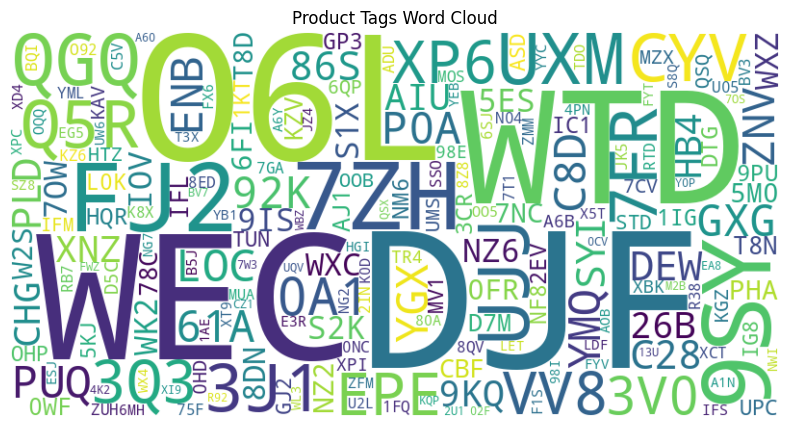

In [20]:
# 9. Product Tags Word Cloud
from wordcloud import WordCloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(" ".join(df['Product Tags'].dropna()))
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Product Tags Word Cloud")
plt.show()

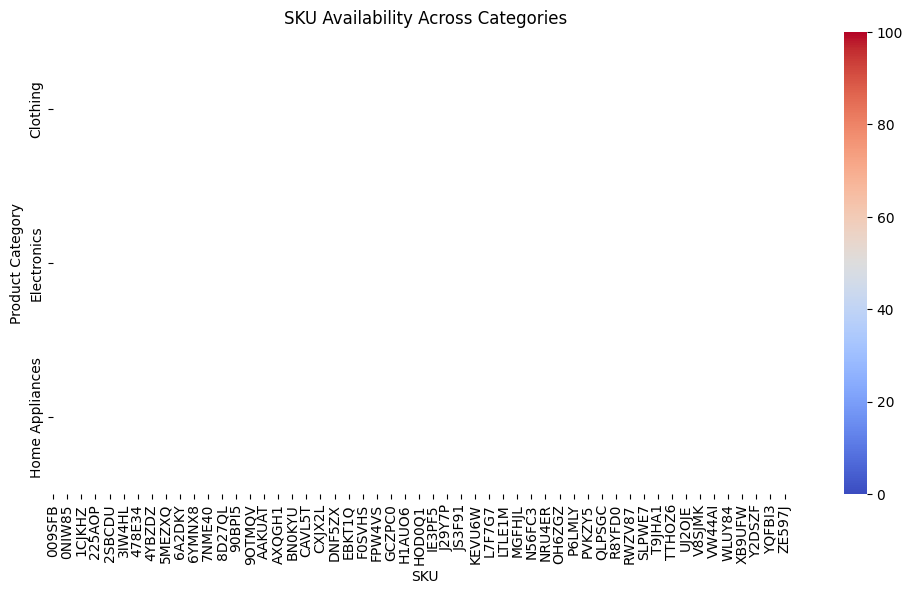

In [21]:
sku_pivot = df.pivot_table(index="Product Category", columns="SKU", values="Stock Quantity", aggfunc="sum", fill_value=0)
plt.figure(figsize=(12, 6))
sns.heatmap(sku_pivot, cmap="coolwarm", linewidths=0.5)
plt.title("SKU Availability Across Categories")
plt.xlabel("SKU")
plt.ylabel("Product Category")
plt.show()

## Predictive modeling

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
import squarify

In [23]:
# Drop non-numeric columns that won't be useful for training
categorical_columns = ['Product ID', 'Product Name', 'Product Description', 'SKU', 'Product Tags', 'Product Dimensions']
df = df.drop(columns=categorical_columns)

In [24]:
# Label Encoding for categorical columns
label_encoders = {}
categorical_features = ['Product Category', 'Color/Size Variations']
for col in categorical_features:
    label_encoders[col] = LabelEncoder()
    df[col] = label_encoders[col].fit_transform(df[col])

In [25]:
# Handling missing values (if any)
df.fillna(df.median(), inplace=True)

In [26]:
# Splitting features and target
target_column = 'Product Ratings'  # Assuming we predict product ratings
X = df.drop(columns=[target_column])
y = df[target_column]

In [27]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
datetime_cols = X_train.select_dtypes(include=['datetime64']).columns

for col in datetime_cols:
    X_train[col] = X_train[col].astype('int64') // 10**9  # Convert to UNIX timestamp
    X_test[col] = X_test[col].astype('int64') // 10**9

In [29]:
print(df.dtypes)

Product Category                  int64
Price                           float64
Stock Quantity                    int64
Warranty Period                   int64
Manufacturing Date       datetime64[ns]
Expiration Date          datetime64[ns]
Color/Size Variations             int64
Product Ratings                   int64
dtype: object


In [30]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [31]:
# Dictionary to store model accuracy
model_accuracies = {}

In [32]:
# 1. Random Forest Classifier
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
model_accuracies['Random Forest'] = accuracy_score(y_test, y_pred) * 100

In [33]:
# 2. Support Vector Machine
svm = SVC()
svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)
model_accuracies['SVM'] = accuracy_score(y_test, y_pred) * 100

In [34]:
# 3. Logistic Regression
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
model_accuracies['Logistic Regression'] = accuracy_score(y_test, y_pred) * 100

In [35]:
# 4. K-Nearest Neighbors
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
model_accuracies['KNN'] = accuracy_score(y_test, y_pred) * 100

In [36]:
# 5. Decision Tree Classifier
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
model_accuracies['Decision Tree'] = accuracy_score(y_test, y_pred) * 100

In [37]:
# 6. Naive Bayes
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred = gnb.predict(X_test)
model_accuracies['Naive Bayes'] = accuracy_score(y_test, y_pred) * 100

In [38]:
# Print model accuracies
for model, accuracy in model_accuracies.items():
    print(f"{model}: {accuracy:.2f}%")

Random Forest: 20.55%
SVM: 19.85%
Logistic Regression: 19.45%
KNN: 21.30%
Decision Tree: 20.80%
Naive Bayes: 19.10%


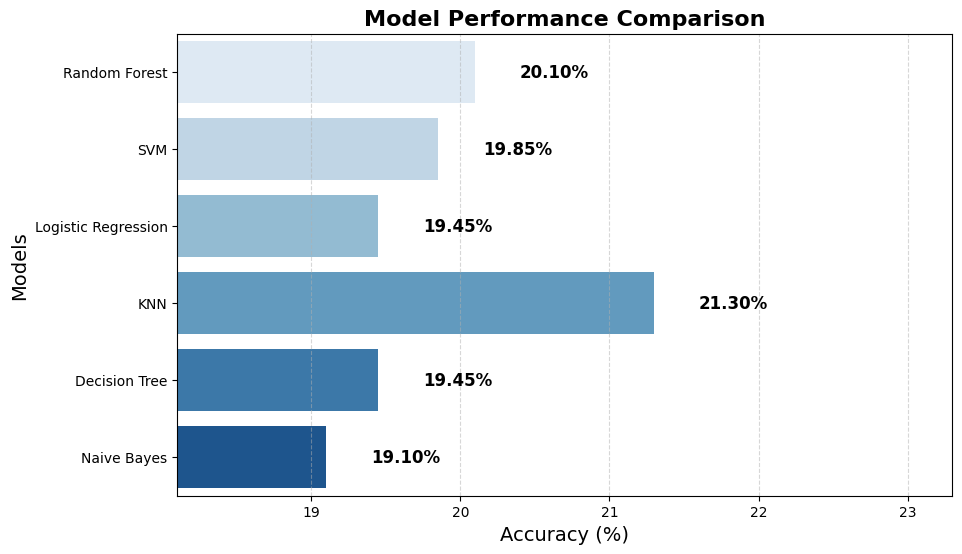

In [39]:
# Model names and their respective scores
models = ["Random Forest", "SVM", "Logistic Regression", "KNN", "Decision Tree", "Naive Bayes"]
scores = [20.10, 19.85, 19.45, 21.30, 19.45, 19.10]

# Set color palette
colors = sns.color_palette("Blues", len(models))

# Create figure and axis
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=scores, y=models, palette=colors)

# Annotate bars with their values
for index, value in enumerate(scores):
    ax.text(value + 0.3, index, f"{value:.2f}%", va='center', fontsize=12, fontweight='bold', color='black')

# Formatting the plot
plt.xlabel("Accuracy (%)", fontsize=14)
plt.ylabel("Models", fontsize=14)
plt.title("Model Performance Comparison", fontsize=16, fontweight='bold')
plt.xlim(min(scores) - 1, max(scores) + 2)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

## Thankyou...pls upvote!!!